## Lab 4

In [81]:
# Imports as usual...

import pandas as pd
import statistics as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import graphviz
from scipy import stats

**Q1.**

OK, a warm-up, just to get started.

1. Set up a grid of $K$ equally spaced values between 0 and 1, `{1/K, 2/K, ..., K/K}`.
2. Draw a point from the grid at random with equal probability.
3. For a very small $K$, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase $K$?

In [82]:
# 1. 

k = 10
grid = []

for i in range(k+1):
    grid_val = i/k
    grid.append(grid_val)

print(grid)

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


In [105]:
# 2.

point = rng.choice(grid) # pyright: ignore[reportUndefinedVariable]
print(point)

0.2


Text(0.5, 0, 'results')

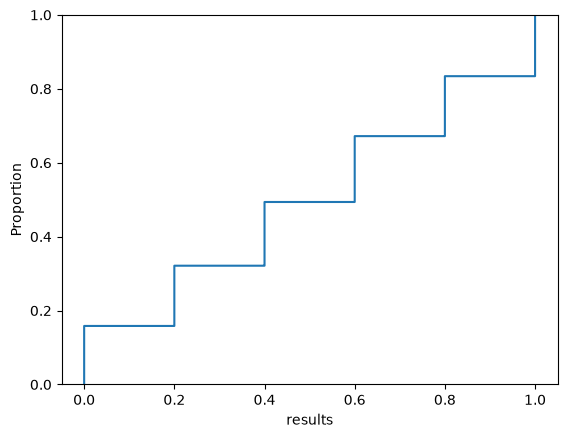

In [107]:
# 3. 

k = 5
b = 5000
grid = []
results = []

for i in range(k+1):
    grid_val = i/k
    grid.append(grid_val)

for i in range(5000):
    point = rng.choice(grid) # type: ignore
    results.append(point)

# Plot ECDF
sns.ecdfplot(x=results) # Used Claude Opus 5.5 for this... I was unsure about the parameters. To use the data that we placed in the results array, I was unsure
# as to whether I needed the data= or x= param
plt.xlabel("results")


5. In order to see what distribution the simulation approaches as K increases, we need to drastically increase K and observe the results...

Try k = 500 to start

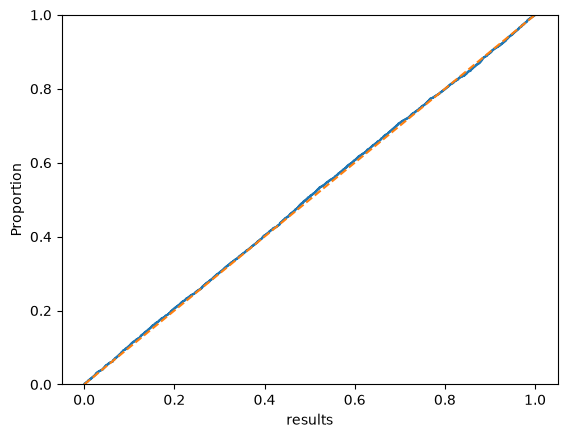

In [112]:
# 4.

k = 500
b = 5000
grid = []
results = []

for i in range(k+1):
    grid_val = i/k
    grid.append(grid_val)

for i in range(5000):
    point = rng.choice(grid) # type: ignore
    results.append(point)

# Plot ECDF
sns.ecdfplot(x=results) # Used Claude Opus 5.5 for this... I was unsure about the parameters. To use the data that we placed in the results array, I was unsure
# as to whether I needed the data= or x= param
plt.xlabel("results")

x = np.linspace(0, 1, 400) # Provided by Claude Opus 5.5 to test my educated guess with the uniform CDF
plt.plot(x, stats.uniform.cdf(x, loc=0, scale=1), "--")

This clearly approaches a uniform distribution, as k gets very large. I used Claude Opus 5.5 to get the lines of code that allows me to test the ECDF that we obtained, vs the uniform CDF, and the two of are very much in line with one another (CDF is orange line)

**Q2.** 

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

In [35]:
# 1.
n = 32
rng = np.random.default_rng(seed = 100)
data = rng.uniform(-np.sqrt(3), np.sqrt(3), size=32) # Used Claude Opus 5.5 for this... was not aware that uniform was part of rng package, and thought it was from np
print(data)

[ 1.16041041  0.33447296 -0.73139919 -1.5832622   1.64078696  0.33418779
  1.0055011   1.42145731  0.65178613 -1.07390104  1.66789211 -0.74568234
  0.4478154   0.2807186   0.34610627  0.12210302  1.71742227  0.00674144
  0.93884974 -0.02022419  1.72399502  1.65799497 -0.36869111 -0.61686898
  1.25463058  1.03689185  0.66313516 -0.31690346 -0.38186478 -1.27600739
  0.43473605 -1.44660409]


In [36]:
# 2.
mean = np.mean(data)
# print(mean)
res = mean * np.sqrt(n)
print(res)

1.818365101776832


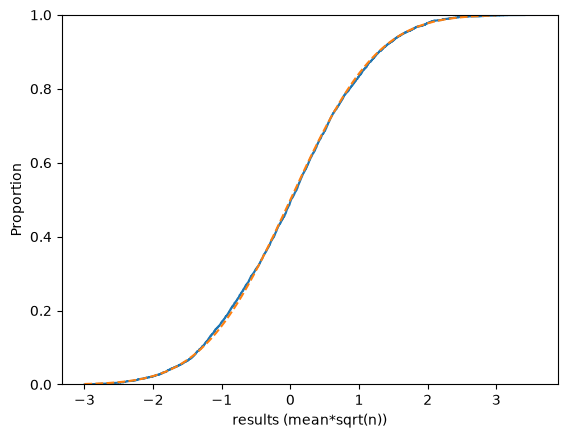

In [ ]:
# 3.

b = 5000
results_array = []
rng = np.random.default_rng(seed = 100)

for i in range(5000):
    data = rng.uniform(-(np.sqrt(3)), np.sqrt(3), size=32)
    mean = np.mean(data)
    res = mean * np.sqrt(n)
    results_array.append(res)

# Check
# print(len(results_array))
# print(results_array)

sns.ecdfplot(x=results_array) # Used Claude Opus 5.5 for this... I was unsure about the parameters. To use the data that we placed in the results array, I was unsure
# as to whether I needed the data= or x= param
plt.xlabel("results (mean*sqrt(n))")

x = np.linspace(-3, 3, 200) # Used Claude Opus 5.5 to print the TRUE Normal CDF on our rage
plt.plot(x, stats.norm.cdf(x, loc=0, scale=1), "--", label="Normal CDF (formula)") # I did not know how to do this, nor did I know any of the parameters

Upon first glance of the ECDF, we can make an educated guess as to the distribution as n gets infinitely large. We can rule out the uniform distribution immidiately, as ECDFs for that one sit at a constant 1. ECDF x-values for Beta stay between 0 and 1 so it cannot be that. And the values for all of the other distributions other than normal cannot have x-values below 0, so those can be ruled out.

In order to confirm our "educated guess" we need to plot the normal CDF (mean 0, sd 1) on the interval we specfied, and then compare. Considering our ECDF aligns very well with the CDF on our interval, we know that this simulation follows a normal distribution as n approaches infinity.



**Q3.** 

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability $p$, and we want to study the distribution of the survivors. 

1. Flip `n = 40` coins, which each come up heads with probability $p = 1/2$ and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, `n * p`.
3. Divide by the standard deviation `sqrt( n * p * (1-p) )`.
4. Repeat the above process `b = 5_000` times and plot the ECDF.
5. What distribution does this approach as $n$ increases?
6. How do the results change as you adjust $p$?

In [61]:
# 1.

n = 40
p= 0.5
data = (rng.integers(0, 2, size=n))
print(data)

[0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1 1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 1 1 0
 0 1 1]


In [62]:
# 2.

# 0 = tails
# 1 = heads

head_count = 0
for num in data:
    if num == 1:
        head_count+=1
    else:
        continue

# print(head_count)

result = head_count - (n*p)
print(result)

1.0


In [63]:
# 3. 

final_result = result / (np.sqrt(n*p*(1-p)))
print(final_result)

0.31622776601683794


Text(0.5, 0, 'final results')

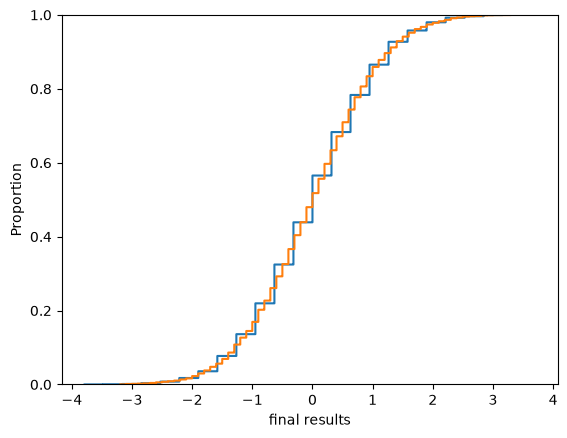

In [70]:
# 4.

n = 40
p= 0.5
b = 5000
final_results = []

for i in range(5000):
    data = (rng.integers(0, 2, size=n))
    head_count = 0
    for num in data:
        if num == 1:
            head_count+=1
        else:
            continue

    result = head_count - (n*p)
    final_result = result / (np.sqrt(n*p*(1-p)))
    final_results.append(final_result)

# ECDF
sns.ecdfplot(x=final_results) # Used Claude Opus 5.5 for this... I was unsure about the parameters. To use the data that we placed in the results array, I was unsure
# as to whether I needed the data= or x= param
plt.xlabel("final results")

n_2 = 400
p= 0.5
b = 5000
final_results_2 = []

for i in range(5000):
    data_2 = (rng.integers(0, 2, size=n_2))
    head_count_2 = 0
    for num in data_2:
        if num == 1:
            head_count_2+=1
        else:
            continue

    result_2 = head_count_2 - (n_2*p)
    final_result_2 = result_2 / (np.sqrt(n_2*p*(1-p)))
    final_results_2.append(final_result_2)

sns.ecdfplot(x=final_results_2) # Used Claude Opus 5.5 for this... I was unsure about the parameters. To use the data that we placed in the results array, I was unsure
# as to whether I needed the data= or x= param
plt.xlabel("final results")




5. This too approaches a normal distribution as n approaches infinity. The difference between this ECDF and the other one, is the fact that in the RNG generation step, there are only two integer values that can be obtained, 0 and 1, so only certain values are possible (hence the starcase shape). This can be seen in the graph above, in which n = 400 was used rather than 40 (orange).

In order to do this, we would need to change the data variable. As it stands right now, the RNG is grabbing each value (0 and 1) with a 50/50 chance. I did not know how to change it, so I used Claude Opus 5.5 to give me the line of code that does so, and I understand how it works now. It takes in an array of all of the random values, and checks if each is less than declared p. It then stores that as an array of Ts and Fs and then changes it to an array of 0s and 1s using astype(int)

Text(0.5, 0, 'final results')

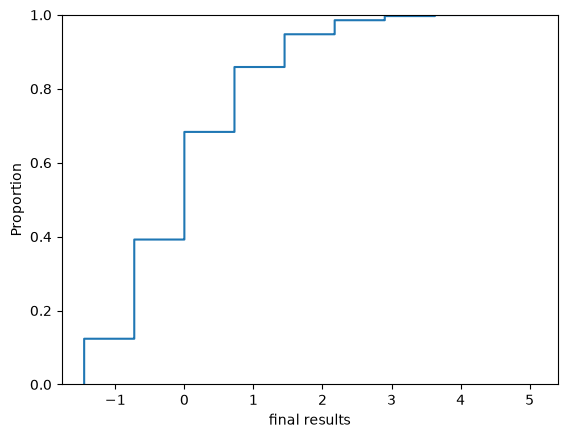

In [77]:
# p = 0.25 
n = 40
p= 0.05
b = 5000
final_results = []

for i in range(5000):
    data = (rng.random(n) < p).astype(int)
    head_count = 0
    for num in data:
        if num == 1:
            head_count+=1
        else:
            continue

    result = head_count - (n*p)
    final_result = result / (np.sqrt(n*p*(1-p)))
    final_results.append(final_result)

# ECDF
sns.ecdfplot(x=final_results) # Used Claude Opus 5.5 for this... I was unsure about the parameters. To use the data that we placed in the results array, I was unsure
# as to whether I needed the data= or x= param
plt.xlabel("final results")

6. (see graph above) As p decreases, the size of the stairs increases, and the graph gets shifted towards lower final result values. This makes sense, as with lower probabilities of getting heads, youd expect less of them, and more of the final results values to be clustered lower considering the more presence of tails.